# Fourier and Convolution for Images

- Interpret image spectrum
- Implement and verify simple image filtering operations


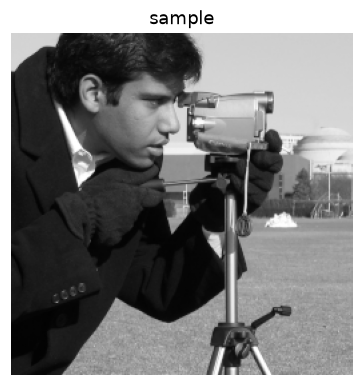

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from skimage import data, img_as_float

plt.rcParams.update({"figure.dpi": 110, "font.size": 10})
rng = np.random.default_rng(7)

def panels(images, titles, *, signed=False):
    """for plots of multiple images in a row"""
    fig, axes = plt.subplots(1, len(images), figsize=(4 * len(images), 3.4),
                             squeeze=False, constrained_layout=True)
    limit = max(float(np.max(np.abs(a))) for a in images) if signed else 1.0
    limit = max(limit, 1e-12)
    for ax, a, title in zip(axes.flat, images, titles):
        ax.imshow(a, cmap="RdBu_r" if signed else "gray",
                  vmin=-limit if signed else 0, vmax=limit)
        ax.set_title(title)
        ax.set_axis_off()
    plt.show()

def frequency_grid(shape):
    """return FX, FY arrays of frequencies for a given image shape."""
    fy = np.fft.fftfreq(shape[0])
    fx = np.fft.fftfreq(shape[1])
    return np.meshgrid(fx, fy)  # arrays have image shape, return FX then FY

def spectrum(ax, F, title, vmax=None):
    """centered log magnitude."""
    values = np.log1p(np.abs(np.fft.fftshift(F)))
    h, w = F.shape
    fx = np.fft.fftshift(np.fft.fftfreq(w))
    fy = np.fft.fftshift(np.fft.fftfreq(h))
    extent = [fx[0] - .5/w, fx[-1] + .5/w,
              fy[-1] + .5/h, fy[0] - .5/h]
    artist = ax.imshow(values, cmap="magma", extent=extent, vmin=0, vmax=vmax)
    ax.set(title=title, xlabel="fx (cycles/pixel)", ylabel="fy (cycles/pixel)")
    return artist

image = img_as_float(data.camera())[96:352, 128:384]
H, W = image.shape
y, x = np.indices(image.shape)
FX, FY = frequency_grid(image.shape)
radius = np.hypot(FX, FY)
panels([image], [f"sample"])

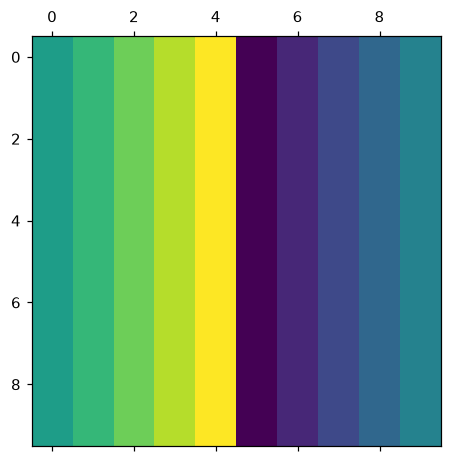

<Figure size 704x528 with 0 Axes>

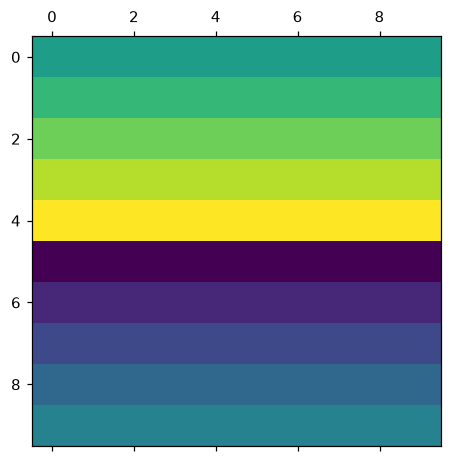

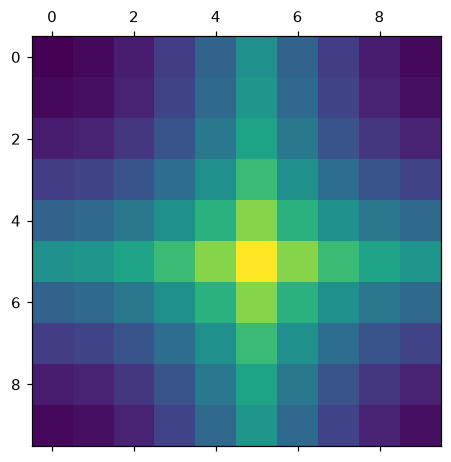

In [2]:
FX, FY = frequency_grid((10, 10))  # https://numpy.org/devdocs/reference/generated/numpy.meshgrid.html
plt.matshow(FX)
plt.figure()
plt.matshow(FY)

def f(x, y):
    return x**2 + y**2
plt.matshow(f(FX, FY))

## Images and Fourier coordinates

- `fft2` transforms both spatial axes of a grayscale image.
- `fftfreq(W)` gives horizontal frequencies in cycles/pixel, in FFT storage order.
- `F[0, 0] / (H*W)` is the mean intensity (the DC component).
- `fftshift` centers frequencies for display. Undo it with `ifftshift` before inversion if you modified a centered spectrum.

### Predict the spectrum of simple waves

For $g[y,x]=\cos(2\pi(k_x x/W+k_y y/H)+\phi)$ with integer frequency bins, the spectrum has two peaks at $\pm(k_y,k_x)$. The vector $(k_x/W,k_y/H)$ is normal to the stripes, not along them (a vertical line is the result of waves "moving horizontally"). With nonzero distinct conjugate bins, each peak has magnitude $HW/2$.

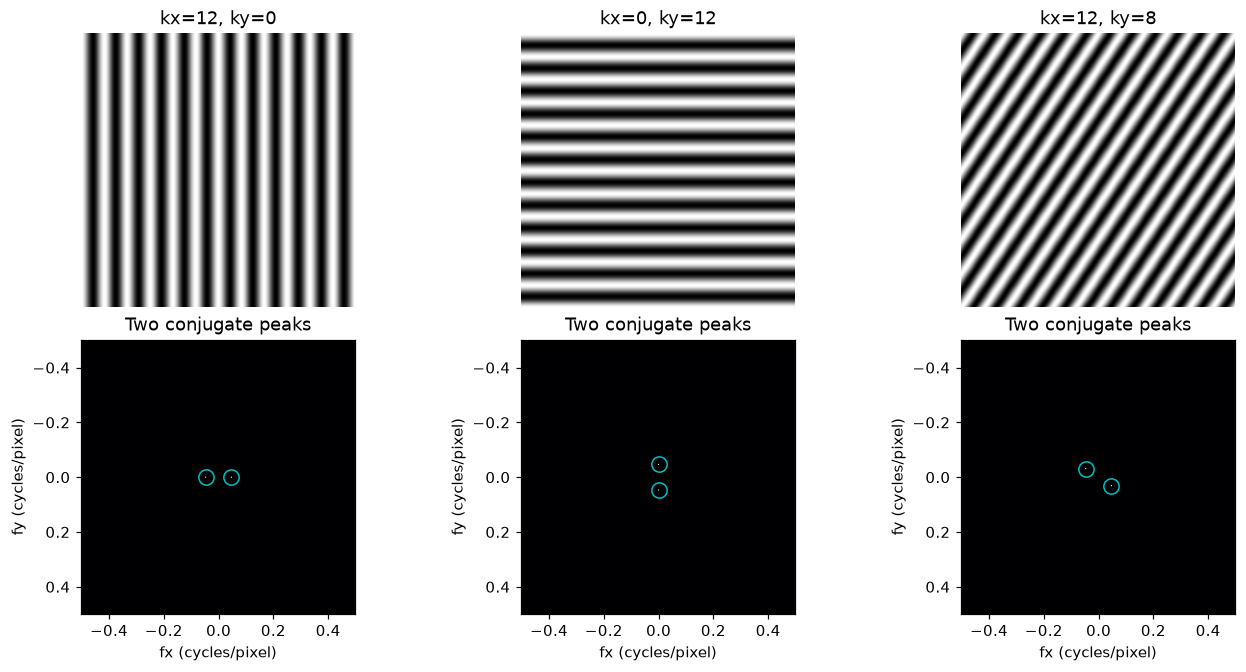

In [3]:
gratings = [(12, 0), (0, 12), (12, 8)]  # (kx, ky)
fig, axes = plt.subplots(2, 3, figsize=(12, 6), constrained_layout=True)
for col, (kx, ky) in enumerate(gratings):
    g = np.cos(2*np.pi*(kx*x/W + ky*y/H))
    G = np.fft.fft2(g)
    axes[0, col].imshow(g, cmap="gray", vmin=-1, vmax=1)
    axes[0, col].set_title(f"kx={kx}, ky={ky}")
    axes[0, col].set_axis_off()
    spectrum(axes[1, col], G, "Two conjugate peaks", vmax=np.log1p(H*W/2))
    axes[1, col].plot([kx/W, -kx/W], [ky/H, -ky/H], "co", fillstyle="none", markersize=10)
    assert np.isclose(abs(G[ky % H, kx % W]), H*W/2)
plt.show()

**Simple exercises:** 
- if I change the values in `gratings`, how does the orientation, spacing, and peak direction changes?
- a noninteger frequency does not fit the periodic tile and spreads energy across bins (spectral leakage). Check this.
- combine multiple waves and plot the resulting FFT's log-magnitude

# Inverting the Fourier Transform

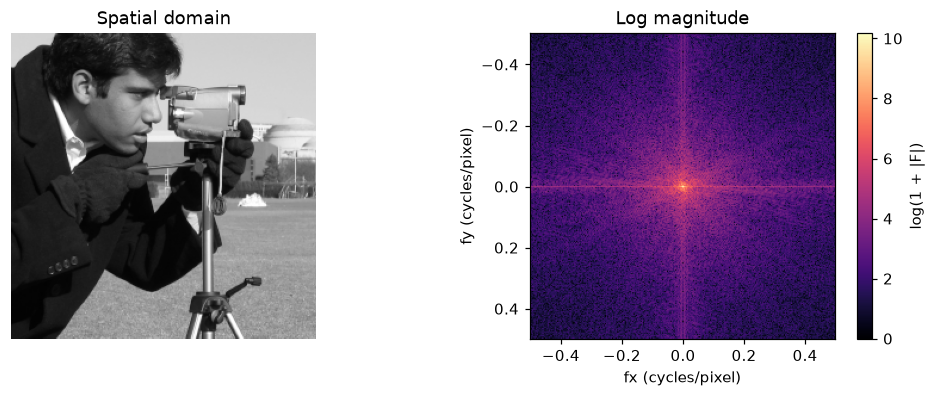

Reconstruction max error: 6.66e-16


In [4]:
F = np.fft.fft2(image)
FX, FY = frequency_grid(image.shape)

reconstructed = np.fft.ifft2(F).real
assert np.allclose(reconstructed, image, atol=1e-12)
assert np.isclose(F[0, 0].real / image.size, image.mean())
assert np.isclose(np.sum(image**2), np.sum(abs(F)**2)/image.size)
fig, axes = plt.subplots(1, 2, figsize=(9, 3.5), constrained_layout=True)
axes[0].imshow(image, cmap="gray", vmin=0, vmax=1)
axes[0].set_title("Spatial domain")
axes[0].set_axis_off()
artist = spectrum(axes[1], F, "Log magnitude")
fig.colorbar(artist, ax=axes[1], label="log(1 + |F|)")
plt.show()
print(f"Reconstruction max error: {np.max(abs(reconstructed-image)):.2e}")

## Magnitude, phase, and translation

- An image is a periodic signal (assuming circular padding), that we can represent as a sum of waves at different frequencies
- if we shift a 2D wave along one axis we only change its phase 
- then, shifting an image only changes its phase, not its magnitude

We show this property by reconstructing a shifted image with the original spectrum F

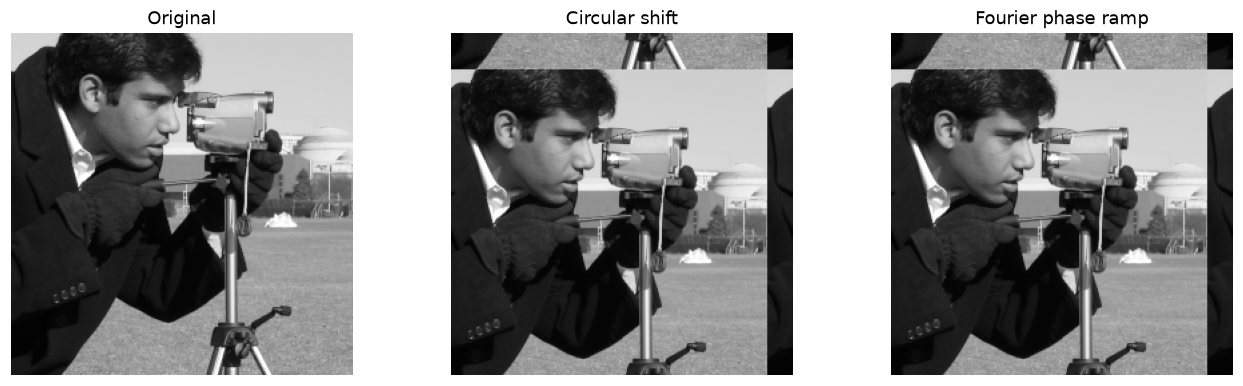

In [5]:
F = np.fft.fft2(image)
FX, FY = frequency_grid(image.shape)

dy, dx = 27, -19
shifted = np.roll(image, (dy, dx), axis=(0, 1))
phase_ramp = np.exp(-2j*np.pi*(FY*dy + FX*dx))
predicted = np.fft.ifft2(F * phase_ramp).real

# Check that the predicted image is the same as the shifted one, and that the Fourier magnitude is unchanged
assert np.allclose(predicted, shifted, atol=1e-12)
assert np.allclose(abs(np.fft.fft2(shifted)), abs(F), atol=1e-10)

panels([image, shifted, predicted], ["Original", "Circular shift", "Fourier phase ramp"])

## Boundaries

### Gaussian blur and boundary choices

- `boundary="fill"` assumes zeros outside the image and can darken borders.
- `boundary="wrap"` tiles the image periodically, joining opposite borders.
- `boundary="symm"` extends by symmetry, including the edge sample.
- `mode="same"` controls output size, not boundary extension.

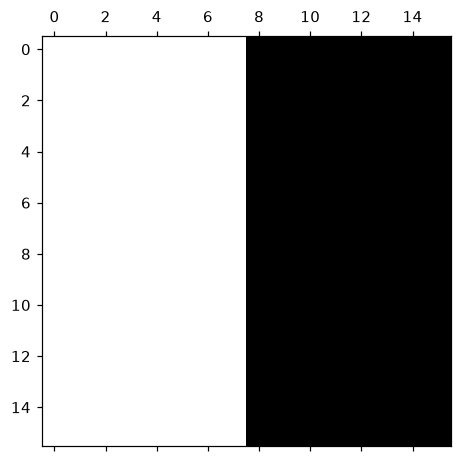

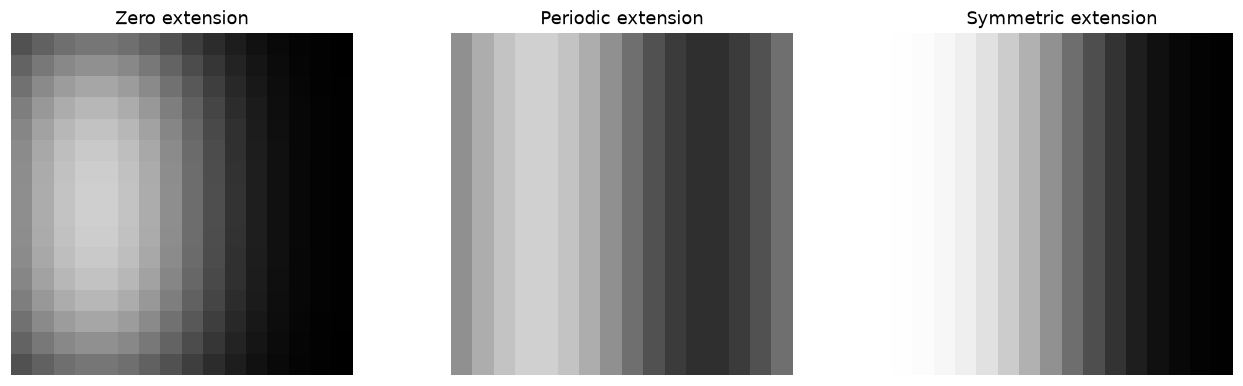

In [6]:
def gaussian_kernel(sigma, truncate=3):
    r = int(np.ceil(truncate*sigma))
    t = np.arange(-r, r+1)
    q = np.exp(-t**2/(2*sigma**2))
    q /= q.sum()
    return np.outer(q, q)

half_white_square = np.ones((16, 16))
half_white_square[:, 8:] = 0
plt.matshow(half_white_square, cmap="gray", vmin=0, vmax=1)

kernel = gaussian_kernel(3)
blurred = {b: signal.convolve2d(half_white_square, kernel, mode="same", boundary=b)
           for b in ["fill", "wrap", "symm"]}
panels(list(blurred.values()), ["Zero extension", "Periodic extension", "Symmetric extension"])

## Blur and Frequency filtering
An ideal low-pass filter is a filter that removes all the frequencies above a threshold, leaving the rest untouched. A Gaussian blur has a smoother frequency response curve.

Notice how in practice, for images, the Gaussian blur has a much nicer output. We can understand this phenomenon by looking at how a sharp edge is transformed by the ideal filter and the Gaussian blur.

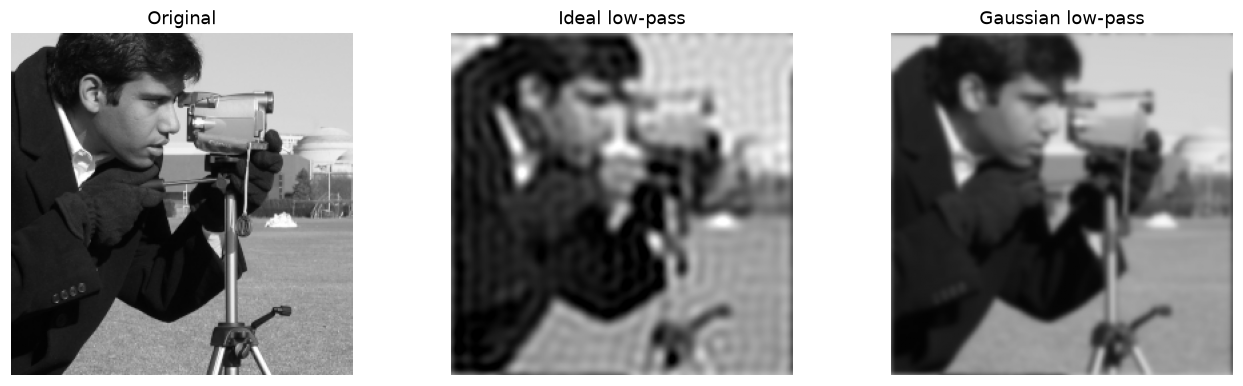

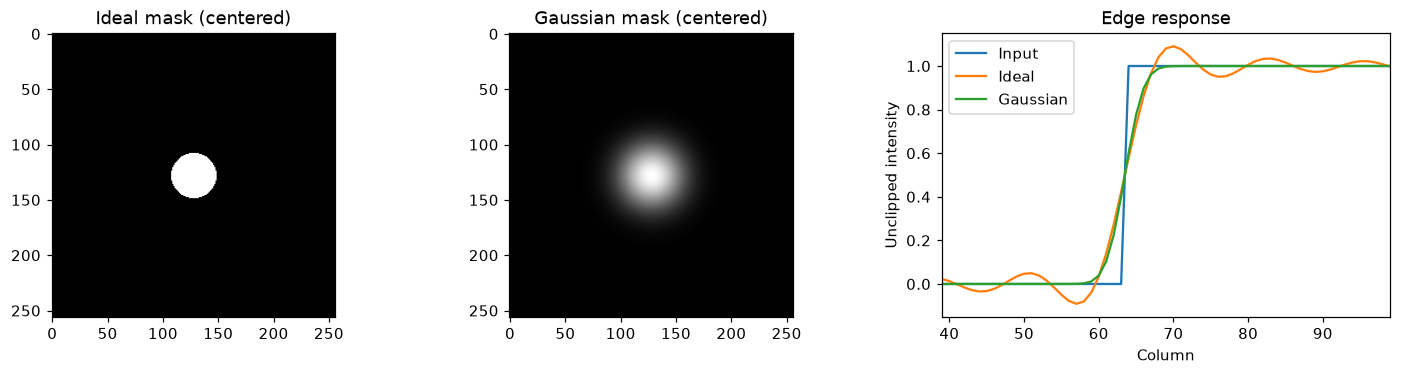

Ideal step range: [-0.091, 1.091]


In [7]:
cutoff = 0.08  # cycles/pixel
sigma = 2.0   # pixels in the continuous Gaussian interpretation

ideal_mask = (radius <= cutoff).astype(float)  # ideal low-pass filter in the frequency domain
smooth_mask = np.exp(-2*np.pi**2*sigma**2*radius**2)  # equivalent to a Gaussian kernel in the spatial domain
ideal_image = np.fft.ifft2(F * ideal_mask).real
smooth_image = np.fft.ifft2(F * smooth_mask).real
panels([image, ideal_image, smooth_image], ["Original", "Ideal low-pass", "Gaussian low-pass"])

step = np.zeros_like(image)
step[:, W//4:3*W//4] = 1
step_F = np.fft.fft2(step)
step_ideal = np.fft.ifft2(step_F * ideal_mask).real
step_smooth = np.fft.ifft2(step_F * smooth_mask).real
fig, axes = plt.subplots(1, 3, figsize=(13, 3.3), constrained_layout=True)
axes[0].imshow(np.fft.fftshift(ideal_mask), cmap="gray", vmin=0, vmax=1)
axes[0].set_title("Ideal mask (centered)")
axes[1].imshow(np.fft.fftshift(smooth_mask), cmap="gray", vmin=0, vmax=1)
axes[1].set_title("Gaussian mask (centered)")
for a, label in [(step, "Input"), (step_ideal, "Ideal"), (step_smooth, "Gaussian")]:
    axes[2].plot(a[H//2], label=label)
axes[2].set(xlim=(W//4-25, W//4+35), xlabel="Column", ylabel="Unclipped intensity", title="Edge response")
axes[2].legend()
plt.show()
print(f"Ideal step range: [{step_ideal.min():.3f}, {step_ideal.max():.3f}]")

### High-pass residuals

The complementary mask $1-M$ gives $f_{\rm high}=f-f_{\rm low}$. High frequencies include edges, fine texture, and some types of noise. Removing them cannot selectively remove noise without also affecting detail.

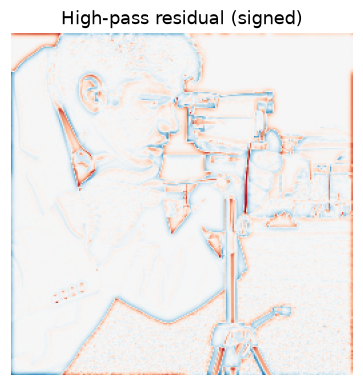

In [8]:
high = np.fft.ifft2(F * (1-smooth_mask)).real
assert np.allclose(high + smooth_image, image)
assert abs(high.mean()) < 1e-12
panels([high], ["High-pass residual (signed)"], signed=True)

## Remove periodic interference

If we know that there is noise at a specific frequency, we can remove it. Since the noise in this case is a real wave, we have to remove the complex pair (two conjugate complex frequencies) that create it.
We reject a small neighborhood around both conjugate peaks.

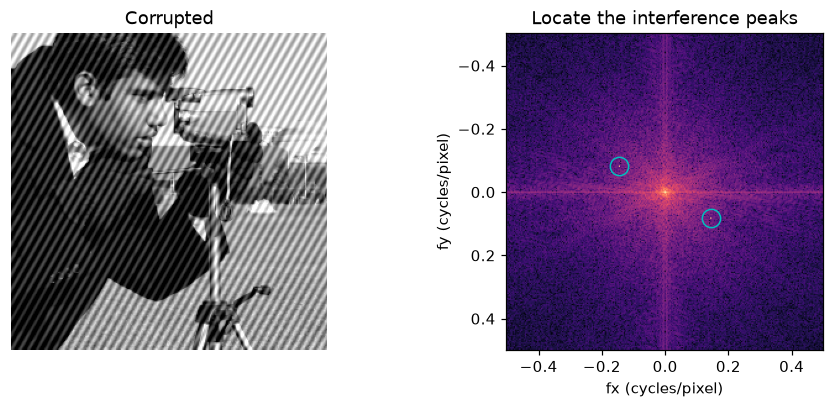

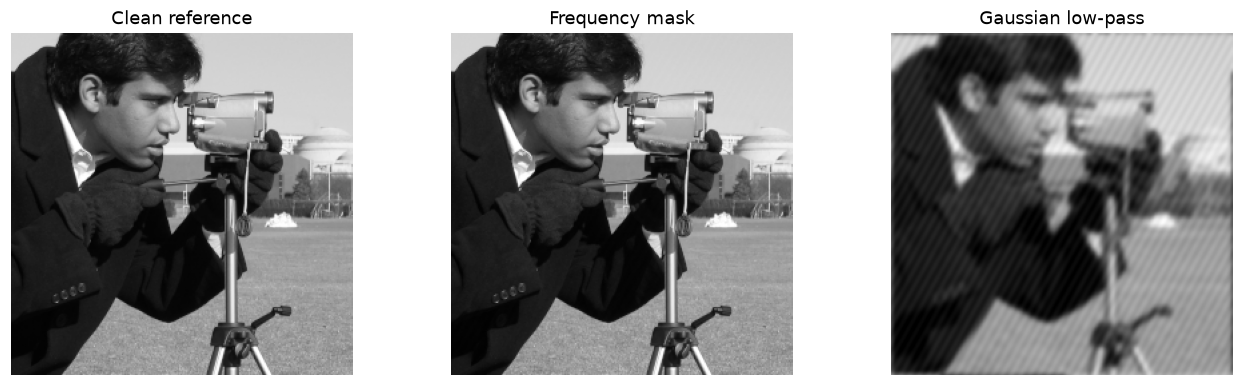

Corrupted  MSE = 0.020000
Notch      MSE = 0.000001
Low-pass   MSE = 0.004886


In [9]:
kx, ky = 37, 21
noise = .20*np.cos(2*np.pi*(kx*x/W + ky*y/H) + .4)
corrupted = image + noise
Fc = np.fft.fft2(corrupted)
fig, axes = plt.subplots(1, 2, figsize=(9, 3.6), constrained_layout=True)
axes[0].imshow(corrupted, cmap="gray", vmin=0, vmax=1)
axes[0].set_title("Corrupted")
axes[0].set_axis_off()
spectrum(axes[1], Fc, "Locate the interference peaks")
# highlight the interference peaks in the spectrum
for sign in [-1, 1]:
    axes[1].plot(sign*kx/W, sign*ky/H, "co", fillstyle="none", markersize=12)
plt.show()

def notch_mask(shape, fx0, fy0, width):
    fx, fy = frequency_grid(shape)
    mask = np.ones(shape)
    for sign in [-1, 1]:
        # distance squared from the center (fx0, fy0) in frequency space
        d2 = (fx - sign*fx0)**2 + (fy - sign*fy0)**2
        # apply a Gaussian notch filter to suppress the interference peaks
        mask *= 1 - np.exp(-d2/(2*width**2))
    return mask

notch = notch_mask(image.shape, kx/W, ky/H, width=1/W)
cleaned = np.fft.ifft2(Fc * notch).real
lowpass_cleaned = np.fft.ifft2(Fc * smooth_mask).real
def mse(a, b):
    return float(np.mean((a-b)**2))

panels([image, cleaned, lowpass_cleaned], ["Clean reference", "Frequency mask", "Gaussian low-pass"])
for name, a in [("Corrupted", corrupted), ("Notch", cleaned), ("Low-pass", lowpass_cleaned)]:
    print(f"{name:10s} MSE = {mse(a, image):.6f}")
assert mse(cleaned, image) < mse(corrupted, image)

# Exercises

## Remove the Interference

replicate what was done in the previous cell with a new image.
- Identify the interference peaks plotting the FFT
- create an appropriate mask
- remove the peaks and reconstruct the original image
- compare against a Gaussian blur

(np.float64(-0.5), np.float64(255.5), np.float64(255.5), np.float64(-0.5))

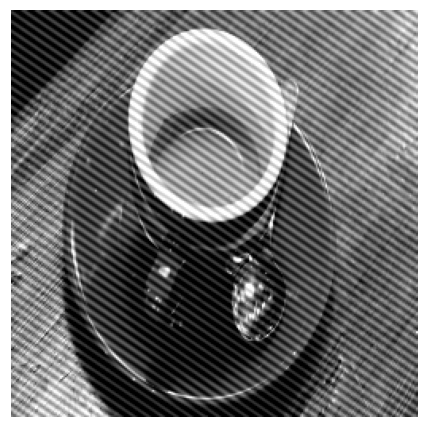

In [10]:
observed = np.load("corrupted_photo.npy")
plt.imshow(observed, cmap="gray", vmin=0, vmax=1)
plt.axis("off")

## Fourier-based Image Compression

Your goal is to reproduce Figure 16.8 https://visionbook.mit.edu/image_processing_fourier.html

- compute the FFT of an image
- discards k% components according to their magnitude
- reconstruct the image
- compare the reconstruction at different compression (k%) levels

(np.float64(-0.5), np.float64(255.5), np.float64(255.5), np.float64(-0.5))

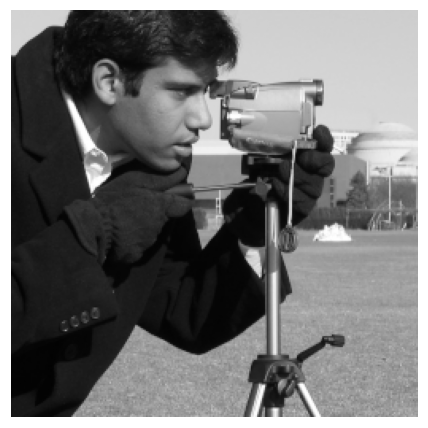

In [11]:
plt.imshow(image, cmap="gray", vmin=0, vmax=1)
plt.axis("off")